<a href="https://colab.research.google.com/github/anvithspatil/indian-equity-derivatives-research/blob/main/Research_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INDIAN EQUITY & DERIVATIVES RESEARCH ENGINE
# ============================================================
#
# Research Question:
# Can a systematic process combining macroeconomic conditions,
# equity fundamentals, market momentum, volatility and
# derivatives positioning generate superior risk-adjusted
# returns in the Indian market?
#
# Author: Anvith S Patil
# Date: September 2026
# ============================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Research environment ready.")

Research environment ready.


In [ ]:
nifty = yf.download(
    "^NSEI",
    start="2018-01-01",
    end="2026-09-02",
    auto_adjust=False,
    progress=False
)

print("Data downloaded successfully.")
print(f"Rows: {len(nifty)}")
print(f"Start: {nifty.index.min().date()}")
print(f"End: {nifty.index.max().date()}")


Data downloaded successfully.
Rows: 2136
Start: 2018-01-02
End: 2026-09-01


In [ ]:
nifty.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,,
2018-01-02,10442.200195,10442.200195,10495.200195,10404.650391,10477.549805,153400
2018-01-03,10443.200195,10443.200195,10503.599609,10429.549805,10482.650391,167300
2018-01-04,10504.799805,10504.799805,10513.000000,10441.450195,10469.400391,174900
2018-01-05,10558.849609,10558.849609,10566.099609,10520.099609,10534.250000,180900
2018-01-08,10623.599609,10623.599609,10631.200195,10588.549805,10591.700195,169000


In [ ]:
nifty.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,,
2026-08-26,24207.750000,24207.750000,24378.599609,24207.750000,24341.949219,244800
2026-08-27,24090.849609,24090.849609,24297.449219,24090.849609,24277.599609,323400
2026-08-28,24175.650391,24175.650391,24188.300781,24076.849609,24122.599609,296100
2026-08-31,24080.400391,24080.400391,24128.699219,23993.599609,24117.550781,710900
2026-09-01,NaN,NaN,24143.150391,23952.550781,24077.550781,0


In [ ]:
# Clean NIFTY dataset

nifty.columns = nifty.columns.get_level_values(0)


nifty = nifty.dropna(subset=["Close"]).copy()


nifty = nifty.sort_index()

print("Cleaned rows:", len(nifty))
print("Start:", nifty.index.min().date())
print("End:", nifty.index.max().date())

nifty.head()

Cleaned rows: 2135
Start: 2018-01-02
End: 2026-08-31


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-02,10442.200195,10442.200195,10495.200195,10404.650391,10477.549805,153400
2018-01-03,10443.200195,10443.200195,10503.599609,10429.549805,10482.650391,167300
2018-01-04,10504.799805,10504.799805,10513.000000,10441.450195,10469.400391,174900
2018-01-05,10558.849609,10558.849609,10566.099609,10520.099609,10534.250000,180900
2018-01-08,10623.599609,10623.599609,10631.200195,10588.549805,10591.700195,169000


In [ ]:
nifty.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-08-25,24334.550781,24334.550781,24334.550781,24115.449219,24175.750000,239500
2026-08-26,24207.750000,24207.750000,24378.599609,24207.750000,24341.949219,244800
2026-08-27,24090.849609,24090.849609,24297.449219,24090.849609,24277.599609,323400
2026-08-28,24175.650391,24175.650391,24188.300781,24076.849609,24122.599609,296100
2026-08-31,24080.400391,24080.400391,24128.699219,23993.599609,24117.550781,710900


In [ ]:
# ============================================================
# MARKET RETURN & VOLATILITY ANALYSIS
# ============================================================

# Daily percentage return
nifty["Daily_Return"] = nifty["Close"].pct_change()

# 20-day rolling annualized volatility
nifty["Volatility_20D"] = (
    nifty["Daily_Return"]
    .rolling(20)
    .std() * np.sqrt(252)
)

# 60-day rolling annualized volatility
nifty["Volatility_60D"] = (
    nifty["Daily_Return"]
    .rolling(60)
    .std() * np.sqrt(252)
)

# 20-day cumulative return
nifty["Return_20D"] = (
    nifty["Close"] / nifty["Close"].shift(20) - 1
)

nifty.tail()

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Volatility_20D,Volatility_60D,Return_20D
Date,,,,,,,,,,
2026-08-25,24334.550781,24334.550781,24334.550781,24115.449219,24175.750000,239500,0.004769,0.087352,0.106800,0.014559
2026-08-26,24207.750000,24207.750000,24378.599609,24207.750000,24341.949219,244800,-0.005211,0.080722,0.107201,-0.001750
2026-08-27,24090.849609,24090.849609,24297.449219,24090.849609,24277.599609,323400,-0.004829,0.081676,0.107477,-0.009306
2026-08-28,24175.650391,24175.650391,24188.300781,24076.849609,24122.599609,296100,0.003520,0.082130,0.107655,-0.008528
2026-08-31,24080.400391,24080.400391,24128.699219,23993.599609,24117.550781,710900,-0.003940,0.055333,0.107911,-0.028009


In [ ]:

total_return = nifty["Close"].iloc[-1] / nifty["Close"].iloc[0] - 1

years = (
    nifty.index[-1] - nifty.index[0]
).days / 365.25

cagr = (
    nifty["Close"].iloc[-1] / nifty["Close"].iloc[0]
) ** (1 / years) - 1

annualized_volatility = (
    nifty["Daily_Return"].std() * np.sqrt(252)
)

print(f"Total Return: {total_return:.2%}")
print(f"CAGR: {cagr:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Observations: {len(nifty)}")

Total Return: 130.61%
CAGR: 10.13%
Annualized Volatility: 16.92%
Observations: 2135


In [ ]:
# ============================================================
# DRAWDOWN ANALYSIS
# ============================================================

nifty["Running_Max"] = nifty["Close"].cummax()

nifty["Drawdown"] = (
    nifty["Close"] / nifty["Running_Max"] - 1
)

max_drawdown = nifty["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -38.44%


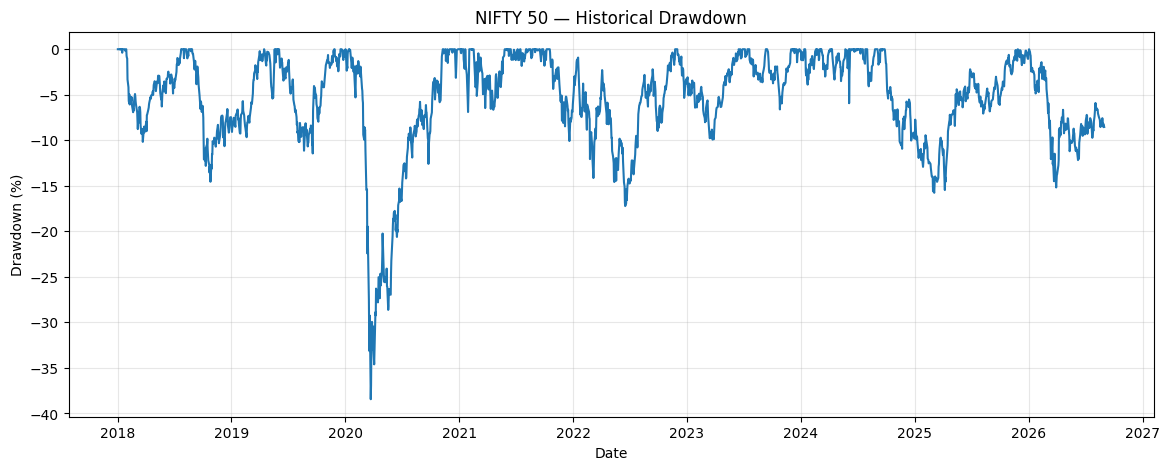

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    nifty.index,
    nifty["Drawdown"] * 100
)

plt.title("NIFTY 50 — Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)

plt.show()

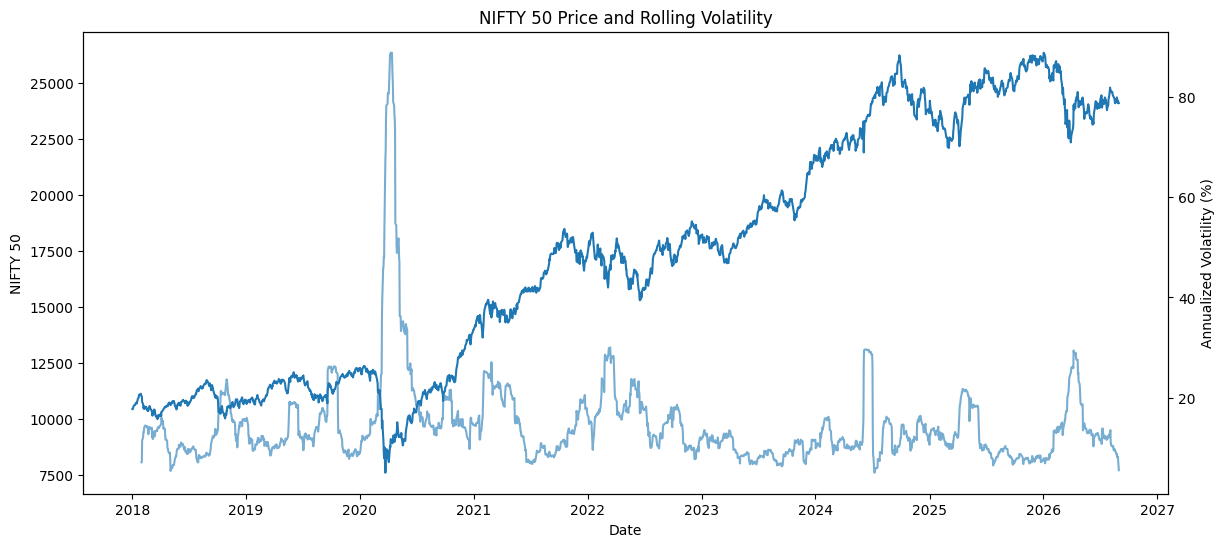

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    nifty.index,
    nifty["Close"],
    label="NIFTY 50"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("NIFTY 50")

ax2 = ax1.twinx()

ax2.plot(
    nifty.index,
    nifty["Volatility_20D"] * 100,
    label="20D Volatility",
    alpha=0.6
)

ax2.set_ylabel("Annualized Volatility (%)")

plt.title("NIFTY 50 Price and Rolling Volatility")
plt.show()

In [13]:
# ============================================================
# INDIA VIX
# ============================================================

vix = yf.download(
    "^INDIAVIX",
    start="2018-01-01",
    end="2026-09-02",
    auto_adjust=False,
    progress=False
)

print("Rows:", len(vix))
print("Start:", vix.index.min().date())
print("End:", vix.index.max().date())

Rows: 2121
Start: 2018-01-01
End: 2026-09-01


In [14]:
vix.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^INDIAVIX,^INDIAVIX,^INDIAVIX,^INDIAVIX,^INDIAVIX,^INDIAVIX
Date,,,,,,
2018-01-01,13.35,13.35,13.61,12.55,12.67,0
2018-01-02,13.69,13.69,13.84,12.61,13.35,0
2018-01-03,13.62,13.62,13.72,12.77,13.69,0
2018-01-04,13.42,13.42,13.79,12.18,13.62,0
2018-01-05,13.11,13.11,13.42,12.42,13.42,0


In [15]:
vix.columns = vix.columns.get_level_values(0)

vix = vix.dropna(subset=["Close"]).copy()
vix = vix.sort_index()

vix = vix[["Close"]].rename(
    columns={"Close": "India_VIX"}
)

vix.tail()

Price,India_VIX
Date,
2026-08-25,11.08
2026-08-26,10.57
2026-08-27,11.07
2026-08-28,10.68
2026-08-31,11.19


In [16]:
research = nifty.join(vix, how="inner")

research[[
    "Close",
    "Daily_Return",
    "Volatility_20D",
    "India_VIX"
]].tail()

Price,Close,Daily_Return,Volatility_20D,India_VIX
Date,,,,
2026-08-25,24334.550781,0.004769,0.087352,11.08
2026-08-26,24207.750000,-0.005211,0.080722,10.57
2026-08-27,24090.849609,-0.004829,0.081676,11.07
2026-08-28,24175.650391,0.003520,0.082130,10.68
2026-08-31,24080.400391,-0.003940,0.055333,11.19


In [17]:
print("Combined observations:", len(research))
print("Missing VIX:", research["India_VIX"].isna().sum())

Combined observations: 2118
Missing VIX: 0


In [18]:
# ============================================================
# MARKET REGIME CLASSIFICATION
# ============================================================

vol_threshold = research["Volatility_20D"].median()

research["Market_Direction"] = np.where(
    research["Return_20D"] >= 0,
    "Bullish",
    "Bearish"
)

research["Volatility_Regime"] = np.where(
    research["Volatility_20D"] >= vol_threshold,
    "High Volatility",
    "Low Volatility"
)

print(f"20D Volatility threshold: {vol_threshold:.2%}")

20D Volatility threshold: 12.29%


In [19]:
research["Market_Regime"] = (
    research["Market_Direction"]
    + " / "
    + research["Volatility_Regime"]
)

research[
    [
        "Close",
        "Return_20D",
        "Volatility_20D",
        "India_VIX",
        "Market_Regime"
    ]
].tail(10)

Price,Close,Return_20D,Volatility_20D,India_VIX,Market_Regime
Date,,,,,
2026-08-18,24154.900391,-0.001356,0.097148,11.39,Bearish / Low Volatility
2026-08-19,24078.300781,0.003419,0.093443,11.32,Bullish / Low Volatility
2026-08-20,24231.849609,0.015176,0.093560,10.76,Bullish / Low Volatility
2026-08-21,24252.000000,0.020387,0.091641,11.20,Bullish / Low Volatility
2026-08-24,24219.050781,0.009297,0.086112,11.53,Bullish / Low Volatility
2026-08-25,24334.550781,0.014559,0.087352,11.08,Bullish / Low Volatility
2026-08-26,24207.750000,-0.001750,0.080722,10.57,Bearish / Low Volatility
2026-08-27,24090.849609,-0.009306,0.081676,11.07,Bearish / Low Volatility
2026-08-28,24175.650391,-0.008528,0.082130,10.68,Bearish / Low Volatility


In [20]:
regime_counts = research["Market_Regime"].value_counts()

regime_percent = (
    regime_counts / len(research) * 100
).round(2)

regime_summary = pd.DataFrame({
    "Days": regime_counts,
    "Percentage": regime_percent
})

regime_summary

,Days,Percentage
Market_Regime,,
Bullish / Low Volatility,744,35.13
Bullish / High Volatility,558,26.35
Bearish / High Volatility,491,23.18
Bearish / Low Volatility,325,15.34


In [21]:
regime_returns = (
    research
    .groupby("Market_Regime")["Daily_Return"]
    .agg(
        Mean_Return="mean",
        Volatility="std",
        Observations="count"
    )
)

regime_returns["Annualized_Return"] = (
    regime_returns["Mean_Return"] * 252
)

regime_returns["Annualized_Volatility"] = (
    regime_returns["Volatility"] * np.sqrt(252)
)

regime_returns["Sharpe"] = (
    regime_returns["Annualized_Return"]
    / regime_returns["Annualized_Volatility"]
)

regime_returns

,Mean_Return,Volatility,Observations,Annualized_Return,Annualized_Volatility,Sharpe
Market_Regime,,,,,,
Bearish / High Volatility,-0.001967,0.016423,491,-0.495679,0.260704,-1.901309
Bearish / Low Volatility,-0.001471,0.006303,324,-0.370672,0.100062,-3.704435
Bullish / High Volatility,0.002639,0.010641,558,0.664924,0.168918,3.936372
Bullish / Low Volatility,0.001217,0.005947,744,0.306560,0.094401,3.247426


## 4. Equity Factor Analysis

We evaluate a representative large-cap Indian equity universe using
fundamental quality, valuation and price momentum factors.

The objective is to determine whether a systematic multi-factor
ranking can identify stocks with comparatively attractive
risk-adjusted characteristics.

In [22]:
# ============================================================
# EQUITY UNIVERSE
# ============================================================

stocks = {
    "RELIANCE": "RELIANCE.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "ICICIBANK": "ICICIBANK.NS",
    "TCS": "TCS.NS",
    "INFY": "INFY.NS",
    "BHARTIARTL": "BHARTIARTL.NS",
    "LT": "LT.NS",
    "ITC": "ITC.NS",
    "AXISBANK": "AXISBANK.NS",
    "SBIN": "SBIN.NS",
    "KOTAKBANK": "KOTAKBANK.NS",
    "MARUTI": "MARUTI.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "HINDUNILVR": "HINDUNILVR.NS",
    "TITAN": "TITAN.NS",
    "BAJFINANCE": "BAJFINANCE.NS",
    "HCLTECH": "HCLTECH.NS",
    "M&M": "M&M.NS",
    "NTPC": "NTPC.NS",
    "ADANIENT": "ADANIENT.NS"
}

print(f"Number of stocks: {len(stocks)}")

Number of stocks: 20


In [23]:
# ============================================================
# DOWNLOAD HISTORICAL PRICE DATA
# ============================================================

tickers = list(stocks.values())

prices = yf.download(
    tickers,
    start="2023-01-01",
    end="2026-09-02",
    auto_adjust=True,
    progress=False
)

# Keep adjusted Close
prices = prices["Close"]

prices.tail()

Ticker,ADANIENT.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,
2026-08-26,3112.000000,1255.0,1085.000000,1902.099976,1298.500000,727.200012,2021.000000,1430.000000,1120.000000,270.25,416.700012,4038.100098,3398.199951,13520.0,334.600006,1298.000000,1052.000000,1899.500000,2270.000000,5100.000000
2026-08-27,3169.000000,1256.0,1083.000000,1878.300049,1282.000000,711.000000,2009.000000,1443.000000,1110.800049,269.00,424.200012,4027.000000,3330.000000,13440.0,330.899994,1282.199951,1042.900024,1913.300049,2248.399902,5139.299805
2026-08-28,3168.500000,1265.0,1079.900024,1882.400024,1316.099976,720.299988,2010.400024,1422.800049,1144.000000,266.00,423.700012,4045.800049,3334.000000,13376.0,330.049988,1287.000000,1047.500000,1920.000000,2342.000000,5169.200195
2026-08-31,2859.100098,1300.0,1057.000000,1811.900024,1312.199951,709.000000,1967.400024,1454.000000,1133.800049,255.50,419.399994,4044.899902,3282.000000,13547.0,327.399994,1277.000000,1060.000000,1984.800049,2399.300049,5102.399902
2026-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# ============================================================
# MOMENTUM FACTORS
# ============================================================

# ============================================================
# FIXED MOMENTUM FACTOR CALCULATION
# ============================================================

def calculate_momentum(series):
    # Remove missing observations for this individual stock
    s = series.dropna()

    # Need at least 252 trading days
    if len(s) < 252:
        return pd.Series({
            "Momentum_3M": np.nan,
            "Momentum_6M": np.nan,
            "Momentum_12M": np.nan
        })

    return pd.Series({
        "Momentum_3M": s.iloc[-1] / s.iloc[-63] - 1,
        "Momentum_6M": s.iloc[-1] / s.iloc[-126] - 1,
        "Momentum_12M": s.iloc[-1] / s.iloc[-252] - 1
    })


momentum = prices.apply(calculate_momentum).T

momentum["Momentum_Score_Raw"] = (
    momentum["Momentum_3M"] * 0.30
    + momentum["Momentum_6M"] * 0.30
    + momentum["Momentum_12M"] * 0.40
)

momentum.sort_values(
    "Momentum_Score_Raw",
    ascending=False
)
momentum

,Momentum_3M,Momentum_6M,Momentum_12M,Momentum_Score_Raw
Ticker,,,,
ADANIENT.NS,-0.037817,0.346314,0.274281,0.202261
AXISBANK.NS,0.038062,-0.051955,0.244740,0.093728
BAJFINANCE.NS,0.216260,0.087143,0.211480,0.175613
BHARTIARTL.NS,0.008688,-0.020551,-0.028641,-0.015015
HCLTECH.NS,0.134637,-0.014606,-0.057172,0.013140
HDFCBANK.NS,-0.044383,-0.180434,-0.242616,-0.164491
HINDUNILVR.NS,-0.044238,-0.143579,-0.246923,-0.155114
ICICIBANK.NS,0.171413,0.067146,0.048975,0.091158
INFY.NS,-0.035766,-0.101300,-0.199736,-0.121014


In [27]:
momentum["Momentum_Score_Raw"] = (
    momentum["Momentum_3M"] * 0.30
    + momentum["Momentum_6M"] * 0.30
    + momentum["Momentum_12M"] * 0.40
)

momentum.sort_values(
    "Momentum_Score_Raw",
    ascending=False
)

,Momentum_3M,Momentum_6M,Momentum_12M,Momentum_Score_Raw
Ticker,,,,
TITAN.NS,0.209913,0.198778,0.410698,0.286887
ADANIENT.NS,-0.037817,0.346314,0.274281,0.202261
SUNPHARMA.NS,0.117916,0.135522,0.256148,0.178491
BAJFINANCE.NS,0.216260,0.087143,0.211480,0.175613
SBIN.NS,0.082461,-0.093112,0.344681,0.134677
AXISBANK.NS,0.038062,-0.051955,0.244740,0.093728
ICICIBANK.NS,0.171413,0.067146,0.048975,0.091158
KOTAKBANK.NS,0.101243,0.017003,0.071581,0.064106
LT.NS,0.026077,0.004354,0.134243,0.062827


In [29]:
# ============================================================
# RISK FACTOR
# ============================================================

returns = prices.pct_change(fill_method=None)

volatility = pd.DataFrame(index=prices.columns)

volatility["Volatility_60D"] = (
    returns
    .tail(60)
    .std() * np.sqrt(252)
)

volatility.sort_values(
    "Volatility_60D"
)
factor_data = momentum.join(volatility)

factor_data["Risk_Adjusted_Momentum"] = (
    factor_data["Momentum_Score_Raw"]
    / factor_data["Volatility_60D"]
)

factor_data.sort_values(
    "Risk_Adjusted_Momentum",
    ascending=False
)

,Momentum_3M,Momentum_6M,Momentum_12M,Momentum_Score_Raw,Volatility_60D,Risk_Adjusted_Momentum
Ticker,,,,,,
TITAN.NS,0.209913,0.198778,0.410698,0.286887,0.187819,1.527463
SUNPHARMA.NS,0.117916,0.135522,0.256148,0.178491,0.149481,1.194066
SBIN.NS,0.082461,-0.093112,0.344681,0.134677,0.178963,0.752541
ADANIENT.NS,-0.037817,0.346314,0.274281,0.202261,0.318667,0.634710
BAJFINANCE.NS,0.216260,0.087143,0.211480,0.175613,0.318085,0.552093
ICICIBANK.NS,0.171413,0.067146,0.048975,0.091158,0.170626,0.534254
AXISBANK.NS,0.038062,-0.051955,0.244740,0.093728,0.217019,0.431888
LT.NS,0.026077,0.004354,0.134243,0.062827,0.194149,0.323600
KOTAKBANK.NS,0.101243,0.017003,0.071581,0.064106,0.228176,0.280950


In [32]:
# ============================================================
# QUALITY FACTOR
# ============================================================

fundamentals["ROE_Score"] = fundamentals["ROE"].rank(
    pct=True
)

fundamentals["Margin_Score"] = fundamentals["Profit_Margin"].rank(
    pct=True
)

fundamentals["Quality_Score"] = (
    0.55 * fundamentals["ROE_Score"] +
    0.45 * fundamentals["Margin_Score"]
)

fundamentals[
    [
        "Stock",
        "ROE",
        "Profit_Margin",
        "Quality_Score"
    ]
].sort_values(
    "Quality_Score",
    ascending=False
)

,Stock,ROE,Profit_Margin,Quality_Score
3,TCS,0.47743,0.18052,0.79750
4,INFY,0.32000,0.16370,0.70625
2,ICICIBANK,0.16074,0.27531,0.65750
16,HCLTECH,0.24067,0.12966,0.57000
5,BHARTIARTL,0.20151,0.13140,0.52375
9,SBIN,0.15177,0.22376,0.49875
1,HDFCBANK,0.13838,0.26787,0.49750
8,AXISBANK,0.13353,0.36031,0.49625
0,RELIANCE,NaN,0.06615,NaN
6,LT,NaN,0.05588,NaN


In [37]:
# ============================================================
# QUALITY FACTOR — ROBUST SCORING
# ============================================================

# Percentile ranks; missing ROE stays missing
fundamentals["ROE_Score"] = fundamentals["ROE"].rank(
    pct=True,
    na_option="keep"
)

fundamentals["Margin_Score"] = fundamentals["Profit_Margin"].rank(
    pct=True,
    na_option="keep"
)

# Average available components
fundamentals["Quality_Score"] = fundamentals[
    ["ROE_Score", "Margin_Score"]
].mean(axis=1, skipna=True)

# Keep a flag so we know which stocks had incomplete ROE data
fundamentals["ROE_Missing"] = fundamentals["ROE"].isna()

quality_table = fundamentals[
    [
        "Stock",
        "ROE",
        "Profit_Margin",
        "ROE_Score",
        "Margin_Score",
        "Quality_Score",
        "ROE_Missing"
    ]
].sort_values(
    "Quality_Score",
    ascending=False
)

quality_table

,Stock,ROE,Profit_Margin,ROE_Score,Margin_Score,Quality_Score,ROE_Missing
15,BAJFINANCE,NaN,0.43495,NaN,1.00,1.0000,True
10,KOTAKBANK,NaN,0.28467,NaN,0.90,0.9000,True
3,TCS,0.47743,0.18052,1.000,0.55,0.7750,False
7,ITC,NaN,0.25938,NaN,0.75,0.7500,True
13,HINDUNILVR,NaN,0.22644,NaN,0.70,0.7000,True
4,INFY,0.32000,0.16370,0.875,0.50,0.6875,False
2,ICICIBANK,0.16074,0.27531,0.500,0.85,0.6750,False
12,SUNPHARMA,NaN,0.20189,NaN,0.60,0.6000,True
16,HCLTECH,0.24067,0.12966,0.750,0.35,0.5500,False
8,AXISBANK,0.13353,0.36031,0.125,0.95,0.5375,False


In [38]:
print("Missing Quality Scores:",
      fundamentals["Quality_Score"].isna().sum())

print("Missing ROE:",
      fundamentals["ROE"].isna().sum())

Missing Quality Scores: 0
Missing ROE: 12


In [39]:
# Data completeness for quality factor

fundamentals["Quality_Data_Complete"] = (
    fundamentals["ROE"].notna() &
    fundamentals["Profit_Margin"].notna()
)

print(
    "Stocks with complete quality data:",
    fundamentals["Quality_Data_Complete"].sum()
)

print(
    "Stocks with incomplete quality data:",
    (~fundamentals["Quality_Data_Complete"]).sum()
)

Stocks with complete quality data: 8
Stocks with incomplete quality data: 12


In [40]:
fundamentals[
    [
        "Stock",
        "ROE",
        "Profit_Margin",
        "Quality_Score",
        "Quality_Data_Complete"
    ]
].sort_values(
    "Quality_Score",
    ascending=False
)

,Stock,ROE,Profit_Margin,Quality_Score,Quality_Data_Complete
15,BAJFINANCE,NaN,0.43495,1.0000,False
10,KOTAKBANK,NaN,0.28467,0.9000,False
3,TCS,0.47743,0.18052,0.7750,True
7,ITC,NaN,0.25938,0.7500,False
13,HINDUNILVR,NaN,0.22644,0.7000,False
4,INFY,0.32000,0.16370,0.6875,True
2,ICICIBANK,0.16074,0.27531,0.6750,True
12,SUNPHARMA,NaN,0.20189,0.6000,False
16,HCLTECH,0.24067,0.12966,0.5500,True
8,AXISBANK,0.13353,0.36031,0.5375,True


In [41]:
fundamentals["PE_Score"] = (-fundamentals["PE"]).rank(
    pct=True,
    na_option="keep"
)

fundamentals["PB_Score"] = (-fundamentals["PB"]).rank(
    pct=True,
    na_option="keep"
)

fundamentals["Valuation_Score"] = fundamentals[
    ["PE_Score", "PB_Score"]
].mean(axis=1, skipna=True)

valuation_table = fundamentals[
    [
        "Stock",
        "PE",
        "PB",
        "PE_Score",
        "PB_Score",
        "Valuation_Score"
    ]
].sort_values(
    "Valuation_Score",
    ascending=False
)

valuation_table

,Stock,PE,PB,PE_Score,PB_Score,Valuation_Score
18,NTPC,10.012229,1.563664,1.00,0.95,0.975
9,SBIN,11.065355,1.535370,0.95,1.00,0.975
8,AXISBANK,14.168263,1.753195,0.90,0.90,0.900
1,HDFCBANK,15.567462,1.807711,0.80,0.85,0.825
2,ICICIBANK,18.590822,2.711279,0.65,0.70,0.675
10,KOTAKBANK,20.853779,2.332589,0.55,0.75,0.650
7,ITC,16.830809,4.606957,0.75,0.50,0.625
0,RELIANCE,23.726664,1.959449,0.45,0.80,0.625
17,M&M,19.819984,3.912247,0.60,0.60,0.600
4,INFY,14.972154,5.098082,0.85,0.35,0.600


In [42]:
# ============================================================
# FINAL MULTI-FACTOR EQUITY MODEL
# ============================================================

# Start with the momentum + volatility dataset
factor_data = momentum.join(volatility)

# Risk-adjusted momentum
factor_data["Risk_Adjusted_Momentum"] = (
    factor_data["Momentum_Score_Raw"]
    / factor_data["Volatility_60D"]
)

# Convert to a cross-sectional percentile score
factor_data["Momentum_Score"] = (
    factor_data["Risk_Adjusted_Momentum"]
    .rank(pct=True)
)

# Convert ticker index into Stock names
factor_data = factor_data.reset_index().rename(
    columns={"index": "Ticker"}
)

factor_data["Stock"] = (
    factor_data["Ticker"]
    .str.replace(".NS", "", regex=False)
)

# Merge with fundamental data
factor_model = fundamentals.merge(
    factor_data,
    on="Stock",
    how="inner"
)

# ------------------------------------------------------------
# Composite score
# ------------------------------------------------------------

factor_model["Composite_Score"] = (
    0.35 * factor_model["Quality_Score"] +
    0.25 * factor_model["Valuation_Score"] +
    0.40 * factor_model["Momentum_Score"]
)

factor_model = factor_model.sort_values(
    "Composite_Score",
    ascending=False
)

factor_model[
    [
        "Stock",
        "Quality_Score",
        "Valuation_Score",
        "Momentum_Score",
        "Composite_Score"
    ]
]

,Stock,Quality_Score,Valuation_Score,Momentum_Score,Composite_Score
9,SBIN,0.5125,0.975,0.90,0.783125
15,BAJFINANCE,1.0000,0.300,0.80,0.745000
10,KOTAKBANK,0.9000,0.650,0.60,0.717500
2,ICICIBANK,0.6750,0.675,0.75,0.705000
8,AXISBANK,0.5375,0.900,0.70,0.693125
12,SUNPHARMA,0.6000,0.275,0.95,0.658750
3,TCS,0.7750,0.425,0.35,0.517500
16,HCLTECH,0.5500,0.475,0.50,0.511250
4,INFY,0.6875,0.600,0.25,0.490625
18,NTPC,0.4500,0.975,0.20,0.481250


In [98]:
top_10 = factor_model[
    [
        "Stock",
        "Quality_Score",
        "Valuation_Score",
        "Momentum_Score",
        "Composite_Score"
    ]
].head(10)

top_10
from google.colab import files

files.download("/content/top_10_equity_factor_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

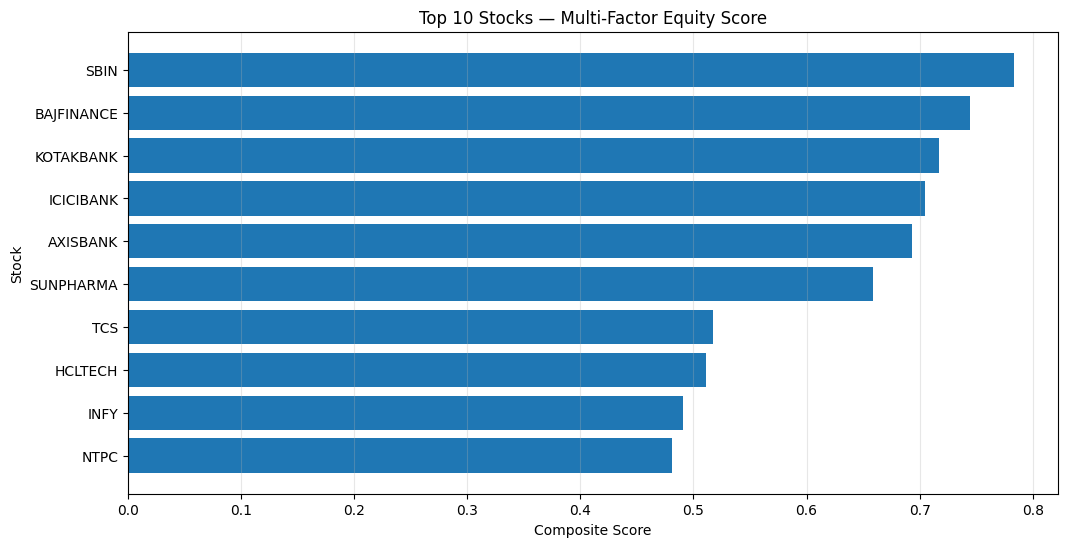

In [44]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_10["Stock"][::-1],
    top_10["Composite_Score"][::-1]
)

plt.title("Top 10 Stocks — Multi-Factor Equity Score")
plt.xlabel("Composite Score")
plt.ylabel("Stock")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [45]:
# Save current equity factor results

top_10.to_csv(
    "top_10_equity_factor_ranking.csv",
    index=False
)

print("Saved: top_10_equity_factor_ranking.csv")

Saved: top_10_equity_factor_ranking.csv


In [47]:
from google.colab import files

files.download("top_10_equity_factor_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
import os

[f for f in os.listdir("/content") if f.lower().endswith(".csv")]

['top_10_equity_factor_ranking.csv', 'option-chain-ED-NIFTY-08-Sep-2026.csv']

In [58]:
# ============================================================
# NSE OPTION CHAIN
# ============================================================

option_file = "/content/option-chain-ED-NIFTY-08-Sep-2026.csv"

options = pd.read_csv(
    option_file,
    header=1
)

print("Original shape:", options.shape)
print(options.columns.tolist())


options = options.iloc[:, 1:-1].copy()


options.columns = (
    options.columns
    .astype(str)
    .str.replace(r"\\n", "", regex=True)
    .str.strip()
)

print("Cleaned shape:", options.shape)
print(options.columns.tolist())

Original shape: (82, 23)
['Unnamed: 0', 'OI\n', 'CHNG IN OI\n', 'VOLUME\n', 'IV\n', 'LTP\n', 'CHNG\n', 'BID QTY\n', 'BID\n', 'ASK\n', 'ASK QTY\n', 'STRIKE\n', 'BID QTY\n.1', 'BID\n.1', 'ASK\n.1', 'ASK QTY\n.1', 'CHNG\n.1', 'LTP\n.1', 'IV\n.1', 'VOLUME\n.1', 'CHNG IN OI\n.1', 'OI\n.1', 'Unnamed: 22']
Cleaned shape: (82, 21)
['OI', 'CHNG IN OI', 'VOLUME', 'IV', 'LTP', 'CHNG', 'BID QTY', 'BID', 'ASK', 'ASK QTY', 'STRIKE', 'BID QTY\n.1', 'BID\n.1', 'ASK\n.1', 'ASK QTY\n.1', 'CHNG\n.1', 'LTP\n.1', 'IV\n.1', 'VOLUME\n.1', 'CHNG IN OI\n.1', 'OI\n.1']


In [59]:
options.columns = [
    "CALL_OI",
    "CALL_CHG_OI",
    "CALL_VOLUME",
    "CALL_IV",
    "CALL_LTP",
    "CALL_CHG",
    "CALL_BID_QTY",
    "CALL_BID",
    "CALL_ASK",
    "CALL_ASK_QTY",
    "STRIKE",
    "PUT_BID_QTY",
    "PUT_BID",
    "PUT_ASK",
    "PUT_ASK_QTY",
    "PUT_CHG",
    "PUT_LTP",
    "PUT_IV",
    "PUT_VOLUME",
    "PUT_CHG_OI",
    "PUT_OI"
]

print("Columns renamed successfully.")
options.head()

Columns renamed successfully.


,CALL_OI,CALL_CHG_OI,CALL_VOLUME,CALL_IV,CALL_LTP,CALL_CHG,CALL_BID_QTY,CALL_BID,CALL_ASK,CALL_ASK_QTY,STRIKE,PUT_BID_QTY,PUT_BID,PUT_ASK,PUT_ASK_QTY,PUT_CHG,PUT_LTP,PUT_IV,PUT_VOLUME,PUT_CHG_OI,PUT_OI
0,5,5,5,-,"1,735.00",-671.10,780,"1,530.65","1,688.80",390,"22,350.00","57,850",1.65,1.70,650,-1.35,1.70,22.29,"52,200","11,365","39,993"
1,-,-,-,-,-,-,780,"1,457.90","1,670.30",780,"22,400.00","7,605",1.85,1.95,520,-1.50,1.85,21.93,"58,269","7,515","33,551"
2,-,-,-,-,-,-,780,"1,416.50","1,613.20",780,"22,450.00","1,690",1.90,2.20,"3,900",-1.45,2.00,21.54,"3,430",117,757
3,219,86,90,-,"1,503.85",-169.40,130,"1,485.80","1,500.15",195,"22,500.00","2,535",2.05,2.20,585,-1.65,2.05,21.01,"1,16,157","19,192","61,422"
4,-,-,-,-,-,-,780,"1,401.20","1,522.45",780,"22,550.00",715,1.95,2.05,65,-1.85,1.95,20.29,"4,501",293,843


In [62]:
# ============================================================
# NUMERIC CLEANING
# ============================================================

for col in options.columns:
    options[col] = (
        options[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("-", np.nan)
    )

    options[col] = pd.to_numeric(
        options[col],
        errors="coerce"
    )


options = options.dropna(subset=["STRIKE"]).copy()

print("Clean rows:", len(options))
options.head(10)

Clean rows: 82


,CALL_OI,CALL_CHG_OI,CALL_VOLUME,CALL_IV,CALL_LTP,CALL_CHG,CALL_BID_QTY,CALL_BID,CALL_ASK,CALL_ASK_QTY,STRIKE,PUT_BID_QTY,PUT_BID,PUT_ASK,PUT_ASK_QTY,PUT_CHG,PUT_LTP,PUT_IV,PUT_VOLUME,PUT_CHG_OI,PUT_OI
0,5.0,5.0,5.0,NaN,1735.00,-671.1,780,1530.65,1688.80,390,22350.0,57850,1.65,1.70,650,-1.35,1.70,22.29,52200.0,11365.0,39993.0
1,NaN,NaN,NaN,NaN,NaN,NaN,780,1457.90,1670.30,780,22400.0,7605,1.85,1.95,520,-1.50,1.85,21.93,58269.0,7515.0,33551.0
2,NaN,NaN,NaN,NaN,NaN,NaN,780,1416.50,1613.20,780,22450.0,1690,1.90,2.20,3900,-1.45,2.00,21.54,3430.0,117.0,757.0
3,219.0,86.0,90.0,NaN,1503.85,-169.4,130,1485.80,1500.15,195,22500.0,2535,2.05,2.20,585,-1.65,2.05,21.01,116157.0,19192.0,61422.0
4,NaN,NaN,NaN,NaN,NaN,NaN,780,1401.20,1522.45,780,22550.0,715,1.95,2.05,65,-1.85,1.95,20.29,4501.0,293.0,843.0
5,NaN,NaN,NaN,NaN,NaN,NaN,780,1275.15,1585.45,780,22600.0,1170,2.20,2.55,3705,-1.45,2.55,20.38,42092.0,2250.0,8256.0
6,NaN,NaN,NaN,NaN,NaN,NaN,780,1215.80,1533.65,780,22650.0,650,2.15,2.65,650,-2.20,2.00,19.16,12340.0,-802.0,1497.0
7,NaN,NaN,NaN,NaN,NaN,NaN,780,1179.00,1370.85,780,22700.0,65,2.50,2.75,2080,-2.00,2.30,18.89,38500.0,3515.0,9809.0
8,NaN,NaN,NaN,NaN,NaN,NaN,780,1133.05,1320.80,780,22750.0,1300,2.45,2.95,1300,-1.50,3.00,18.95,9042.0,452.0,1833.0
9,NaN,NaN,NaN,NaN,NaN,NaN,780,1089.00,1271.15,780,22800.0,520,2.80,3.00,1820,-1.80,3.00,18.33,90124.0,15261.0,36411.0


In [63]:
options.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CALL_OI       70 non-null     float64
 1   CALL_CHG_OI   69 non-null     float64
 2   CALL_VOLUME   70 non-null     float64
 3   CALL_IV       50 non-null     float64
 4   CALL_LTP      70 non-null     float64
 5   CALL_CHG      70 non-null     float64
 6   CALL_BID_QTY  82 non-null     int64  
 7   CALL_BID      82 non-null     float64
 8   CALL_ASK      82 non-null     float64
 9   CALL_ASK_QTY  82 non-null     int64  
 10  STRIKE        82 non-null     float64
 11  PUT_BID_QTY   82 non-null     int64  
 12  PUT_BID       82 non-null     float64
 13  PUT_ASK       82 non-null     float64
 14  PUT_ASK_QTY   82 non-null     int64  
 15  PUT_CHG       70 non-null     float64
 16  PUT_LTP       71 non-null     float64
 17  PUT_IV        67 non-null     float64
 18  PUT_VOLUME    70 non-null     fl

In [64]:
total_call_oi = options["CALL_OI"].sum()
total_put_oi = options["PUT_OI"].sum()

pcr = total_put_oi / total_call_oi

print(f"Total Call OI: {total_call_oi:,.0f}")
print(f"Total Put OI:  {total_put_oi:,.0f}")
print(f"Put-Call Ratio: {pcr:.3f}")

Total Call OI: 1,603,780
Total Put OI:  1,109,331
Put-Call Ratio: 0.692


In [65]:
top_call_oi = options.nlargest(
    10, "CALL_OI"
)[
    ["STRIKE", "CALL_OI", "CALL_CHG_OI", "CALL_IV"]
]

top_put_oi = options.nlargest(
    10, "PUT_OI"
)[
    ["STRIKE", "PUT_OI", "PUT_CHG_OI", "PUT_IV"]
]

print("TOP CALL OI")
display(top_call_oi)

print("\nTOP PUT OI")
display(top_put_oi)

TOP CALL OI


,STRIKE,CALL_OI,CALL_CHG_OI,CALL_IV
37,24200.0,113764.0,64458.0,7.06
63,25500.0,112797.0,59990.0,16.26
43,24500.0,111247.0,54102.0,8.63
35,24100.0,98777.0,68580.0,6.39
33,24000.0,88829.0,67517.0,5.09
53,25000.0,84605.0,29279.0,12.50
45,24600.0,83539.0,40776.0,9.13
39,24300.0,77748.0,38104.0,7.62
49,24800.0,76623.0,36495.0,10.76
36,24150.0,64123.0,51770.0,6.63



TOP PUT OI


,STRIKE,PUT_OI,PUT_CHG_OI,PUT_IV
23,23500.0,95304.0,51044.0,12.80
33,24000.0,82309.0,42262.0,13.30
13,23000.0,75584.0,25627.0,16.24
25,23600.0,74386.0,28525.0,12.54
3,22500.0,61422.0,19192.0,21.01
35,24100.0,53318.0,18298.0,14.21
37,24200.0,52747.0,11783.0,15.19
31,23900.0,51524.0,22772.0,12.94
29,23800.0,46394.0,20301.0,12.64
27,23700.0,43174.0,19211.0,12.51


## 6. Derivatives & Volatility Analysis

This section examines whether India VIX, a market-implied
volatility measure, contains information about subsequent
realized volatility in the NIFTY 50.

Research question:
Does elevated India VIX correspond to higher realized
NIFTY volatility over the following 10 trading days?

In [66]:
# ============================================================
# FUTURE REALIZED VOLATILITY
# ============================================================

research["Future_10D_Realized_Vol"] = (
    research["Daily_Return"]
    .rolling(10)
    .std()
    .shift(-10)
    * np.sqrt(252)
)

vol_data = research[
    ["India_VIX", "Future_10D_Realized_Vol"]
].dropna()

vol_data.head()

Price,India_VIX,Future_10D_Realized_Vol
Date,,
2018-01-02,13.69,0.052455
2018-01-03,13.62,0.057853
2018-01-04,13.42,0.055982
2018-01-05,13.11,0.059080
2018-01-08,13.74,0.059726


In [67]:
# ============================================================
# IV/VIX VS FUTURE REALIZED VOLATILITY
# ============================================================

correlation = (
    vol_data["India_VIX"]
    .corr(vol_data["Future_10D_Realized_Vol"])
)

print(
    f"Correlation between India VIX and "
    f"future 10-day realized volatility: {correlation:.3f}"
)

Correlation between India VIX and future 10-day realized volatility: 0.708


In [68]:
x = vol_data["India_VIX"]
y = vol_data["Future_10D_Realized_Vol"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Correlation (r): {r_value:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Slope: {slope:.4f}")

Correlation (r): 0.708
R-squared: 0.501
P-value: 0.000000
Slope: 0.0099


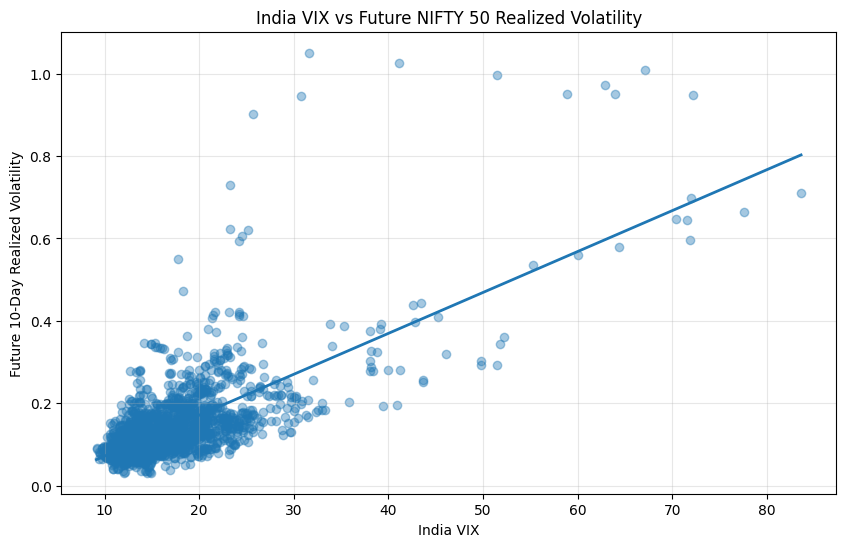

In [69]:
plt.figure(figsize=(10, 6))

plt.scatter(
    vol_data["India_VIX"],
    vol_data["Future_10D_Realized_Vol"],
    alpha=0.4
)

# Regression line
x_line = np.linspace(
    vol_data["India_VIX"].min(),
    vol_data["India_VIX"].max(),
    100
)

y_line = intercept + slope * x_line

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("India VIX")
plt.ylabel("Future 10-Day Realized Volatility")
plt.title("India VIX vs Future NIFTY 50 Realized Volatility")
plt.grid(alpha=0.3)

plt.show()

In [70]:
vix_threshold = research["India_VIX"].median()

research["VIX_Regime"] = np.where(
    research["India_VIX"] >= vix_threshold,
    "High VIX",
    "Low VIX"
)

vix_regime_analysis = (
    research
    .groupby("VIX_Regime")["Future_10D_Realized_Vol"]
    .agg(
        Average_Future_Volatility="mean",
        Median_Future_Volatility="median",
        Observations="count"
    )
)

vix_regime_analysis

,Average_Future_Volatility,Median_Future_Volatility,Observations
VIX_Regime,,,
High VIX,0.176471,0.147194,1059
Low VIX,0.104275,0.097339,1049


In [71]:
print(f"Correlation (r): {r_value:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Slope: {slope:.4f}")

Correlation (r): 0.708
R-squared: 0.501
P-value: 0.000000
Slope: 0.0099


In [72]:
# ============================================================
# OPTIONS POSITIONING
# ============================================================

top_call_oi = options.nlargest(
    10, "CALL_OI"
)[
    ["STRIKE", "CALL_OI", "CALL_CHG_OI", "CALL_IV"]
]

top_put_oi = options.nlargest(
    10, "PUT_OI"
)[
    ["STRIKE", "PUT_OI", "PUT_CHG_OI", "PUT_IV"]
]

print("TOP CALL OI")
display(top_call_oi)

print("\nTOP PUT OI")
display(top_put_oi)

TOP CALL OI


,STRIKE,CALL_OI,CALL_CHG_OI,CALL_IV
37,24200.0,113764.0,64458.0,7.06
63,25500.0,112797.0,59990.0,16.26
43,24500.0,111247.0,54102.0,8.63
35,24100.0,98777.0,68580.0,6.39
33,24000.0,88829.0,67517.0,5.09
53,25000.0,84605.0,29279.0,12.50
45,24600.0,83539.0,40776.0,9.13
39,24300.0,77748.0,38104.0,7.62
49,24800.0,76623.0,36495.0,10.76
36,24150.0,64123.0,51770.0,6.63



TOP PUT OI


,STRIKE,PUT_OI,PUT_CHG_OI,PUT_IV
23,23500.0,95304.0,51044.0,12.80
33,24000.0,82309.0,42262.0,13.30
13,23000.0,75584.0,25627.0,16.24
25,23600.0,74386.0,28525.0,12.54
3,22500.0,61422.0,19192.0,21.01
35,24100.0,53318.0,18298.0,14.21
37,24200.0,52747.0,11783.0,15.19
31,23900.0,51524.0,22772.0,12.94
29,23800.0,46394.0,20301.0,12.64
27,23700.0,43174.0,19211.0,12.51


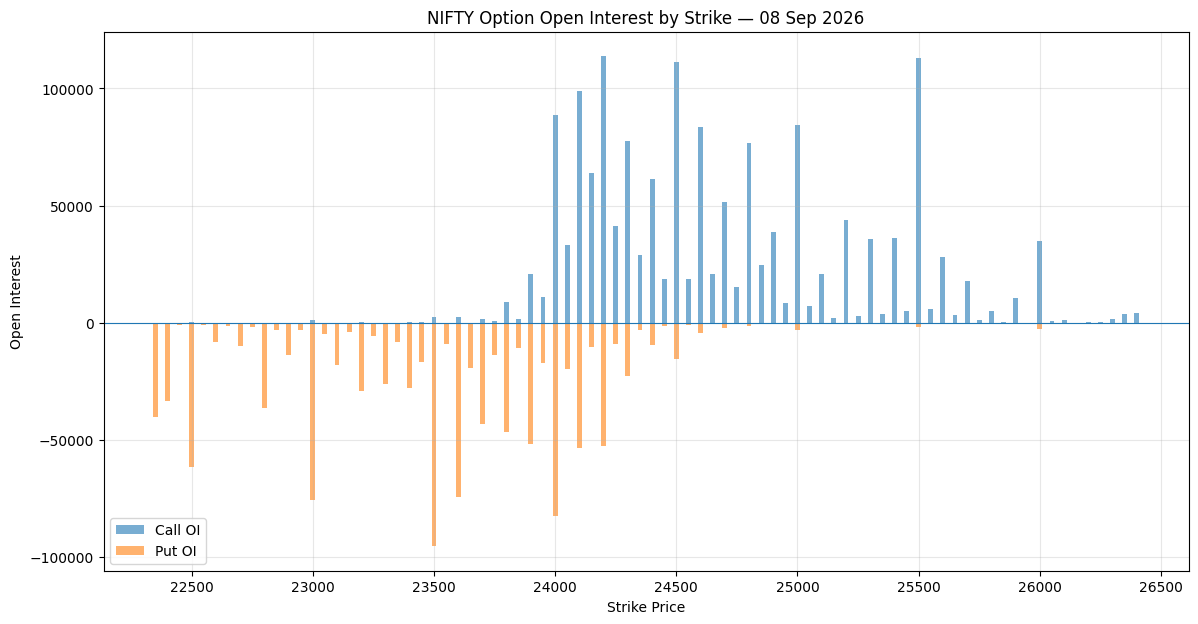

In [73]:
plt.figure(figsize=(14, 7))

plt.bar(
    options["STRIKE"],
    options["CALL_OI"],
    width=20,
    alpha=0.6,
    label="Call OI"
)

plt.bar(
    options["STRIKE"],
    -options["PUT_OI"],
    width=20,
    alpha=0.6,
    label="Put OI"
)

plt.axhline(0, linewidth=0.8)

plt.title("NIFTY Option Open Interest by Strike — 08 Sep 2026")
plt.xlabel("Strike Price")
plt.ylabel("Open Interest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

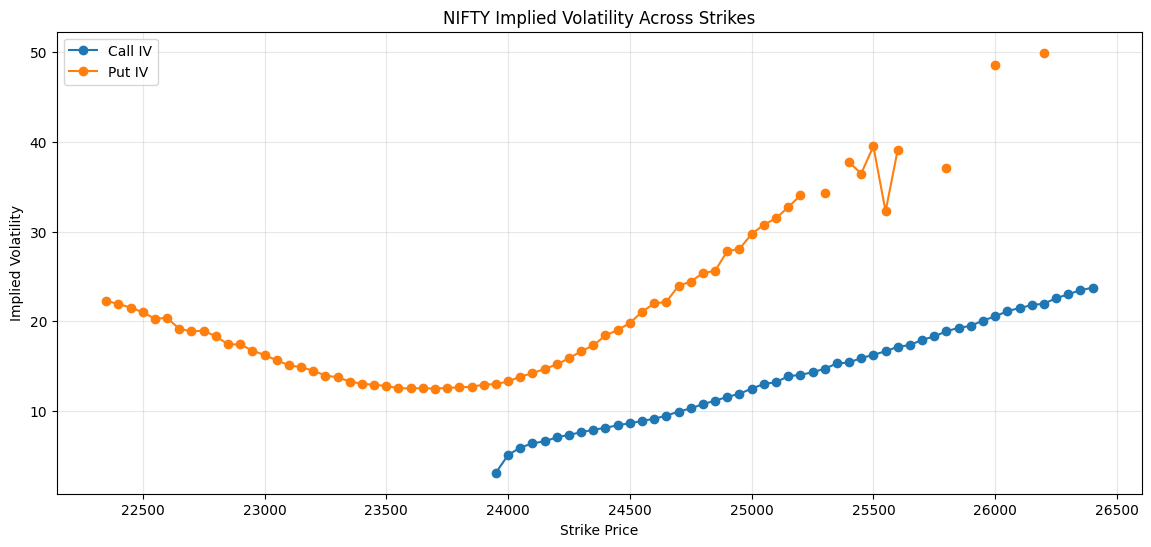

In [74]:
plt.figure(figsize=(14, 6))

plt.plot(
    options["STRIKE"],
    options["CALL_IV"],
    marker="o",
    label="Call IV"
)

plt.plot(
    options["STRIKE"],
    options["PUT_IV"],
    marker="o",
    label="Put IV"
)

plt.title("NIFTY Implied Volatility Across Strikes")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [75]:
max_call_row = options.loc[
    options["CALL_OI"].idxmax()
]

max_put_row = options.loc[
    options["PUT_OI"].idxmax()
]

print(
    f"Highest Call OI: "
    f"{max_call_row['STRIKE']:.0f} "
    f"({max_call_row['CALL_OI']:,.0f} contracts)"
)

print(
    f"Highest Put OI: "
    f"{max_put_row['STRIKE']:.0f} "
    f"({max_put_row['PUT_OI']:,.0f} contracts)"
)

Highest Call OI: 24200 (113,764 contracts)
Highest Put OI: 23500 (95,304 contracts)


In [76]:
spot = research["Close"].iloc[-1]

call_wall = max_call_row["STRIKE"]
put_wall = max_put_row["STRIKE"]

print(f"NIFTY spot: {spot:,.2f}")
print(f"Highest Call OI strike: {call_wall:,.0f}")
print(f"Highest Put OI strike: {put_wall:,.0f}")

print(
    f"Distance to Call OI peak: "
    f"{(call_wall / spot - 1):.2%}"
)

print(
    f"Distance to Put OI peak: "
    f"{(put_wall / spot - 1):.2%}"
)

NIFTY spot: 24,080.40
Highest Call OI strike: 24,200
Highest Put OI strike: 23,500
Distance to Call OI peak: 0.50%
Distance to Put OI peak: -2.41%


## 7. Systematic Strategy & Backtesting

The historical strategy uses only information available at each
point in time. To avoid look-ahead bias, trading signals are lagged
by one trading day.

The strategy combines medium-term momentum with market-regime
information and is evaluated against a buy-and-hold NIFTY 50 benchmark.

In [77]:
# ============================================================
# SYSTEMATIC MOMENTUM STRATEGY
# ============================================================

bt = research.copy()

# Momentum indicator
bt["MA_20"] = bt["Close"].rolling(20).mean()
bt["MA_50"] = bt["Close"].rolling(50).mean()

bt["Momentum_Signal"] = np.where(
    (bt["MA_20"] > bt["MA_50"]) &
    (bt["Return_20D"] > 0),
    1,
    0
)

# Only trade using information available at the previous close
bt["Position"] = bt["Momentum_Signal"].shift(1)

# No position during the initial missing period
bt["Position"] = bt["Position"].fillna(0)

# Strategy daily return
bt["Strategy_Return"] = (
    bt["Position"] * bt["Daily_Return"]
)

bt[[
    "Close",
    "MA_20",
    "MA_50",
    "Return_20D",
    "Momentum_Signal",
    "Position",
    "Strategy_Return"
]].tail(10)

Price,Close,MA_20,MA_50,Return_20D,Momentum_Signal,Position,Strategy_Return
Date,,,,,,,
2026-08-18,24154.900391,24324.094922,24123.158945,-0.001356,0,1.0,-0.005466
2026-08-19,24078.300781,24328.197461,24139.882969,0.003419,1,0.0,-0.000000
2026-08-20,24231.849609,24346.309961,24160.220977,0.015176,1,1.0,0.006377
2026-08-21,24252.000000,24370.537500,24182.028984,0.020387,1,1.0,0.000832
2026-08-24,24219.050781,24381.692578,24193.951992,0.009297,1,1.0,-0.001359
2026-08-25,24334.550781,24399.152637,24203.565000,0.014559,1,1.0,0.004769
2026-08-26,24207.750000,24397.030176,24207.936992,-0.001750,0,1.0,-0.005211
2026-08-27,24090.849609,24385.715137,24208.040000,-0.009306,0,0.0,-0.000000
2026-08-28,24175.650391,24375.317676,24208.193008,-0.008528,0,0.0,0.000000


In [78]:
# ============================================================
# CUMULATIVE PERFORMANCE
# ============================================================

bt["Benchmark_Equity"] = (
    1 + bt["Daily_Return"]
).cumprod()

bt["Strategy_Equity"] = (
    1 + bt["Strategy_Return"]
).cumprod()

bt[[
    "Benchmark_Equity",
    "Strategy_Equity"
]].tail()

Price,Benchmark_Equity,Strategy_Equity
Date,,
2026-08-25,2.278723,1.606316
2026-08-26,2.266849,1.597946
2026-08-27,2.255902,1.597946
2026-08-28,2.263843,1.597946
2026-08-31,2.254924,1.597946


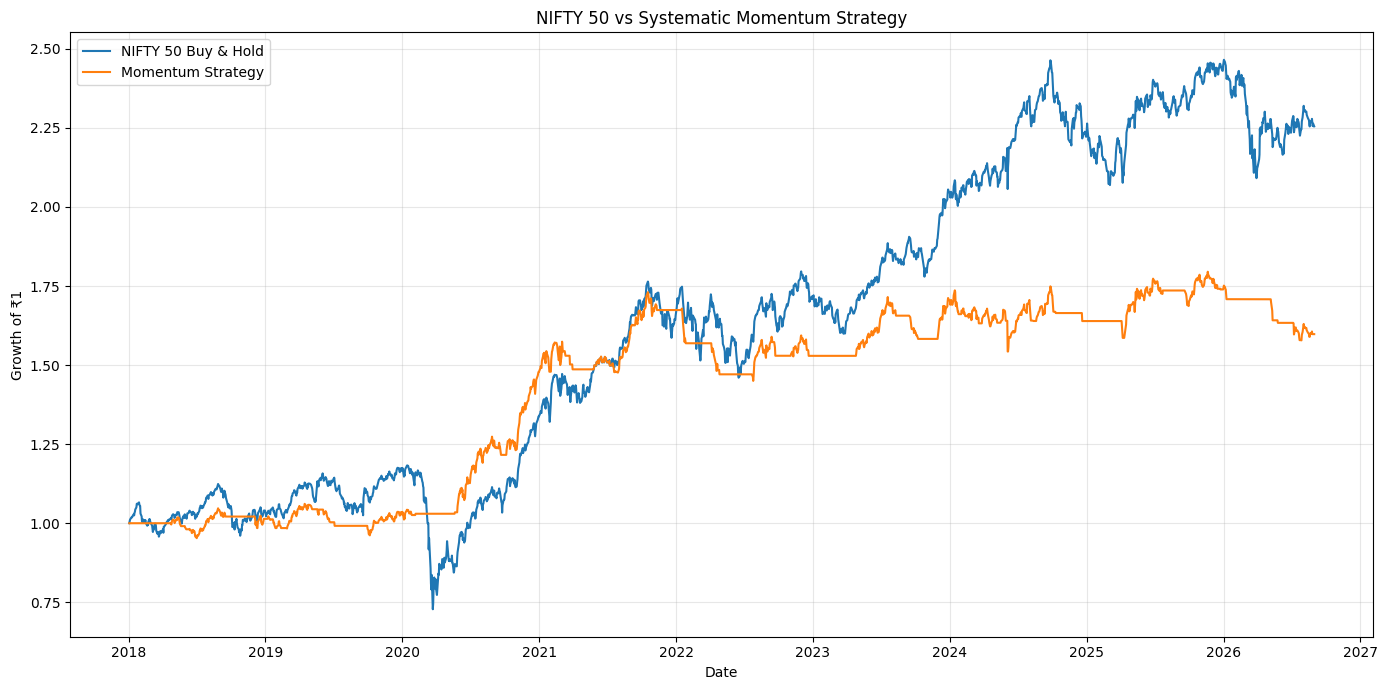

Saved: /content/strategy_vs_nifty.png


In [101]:
# ============================================================
# FINAL STRATEGY VS NIFTY CHART
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    bt.index,
    bt["Benchmark_Equity"],
    label="NIFTY 50 Buy & Hold"
)

plt.plot(
    bt.index,
    bt["Strategy_Equity"],
    label="Momentum Strategy"
)

plt.title("NIFTY 50 vs Systematic Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/strategy_vs_nifty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /content/strategy_vs_nifty.png")

In [81]:
# ============================================================
# PERFORMANCE METRICS
# ============================================================

def performance_metrics(returns, equity_curve, positions=None):

    returns = returns.dropna()
    equity_curve = equity_curve.dropna()

    # Years represented by the actual backtest period
    years = (
        equity_curve.index[-1] - equity_curve.index[0]
    ).days / 365.25

    # CAGR
    cagr = (
        equity_curve.iloc[-1] /
        equity_curve.iloc[0]
    ) ** (1 / years) - 1

    # Annualized volatility
    volatility = returns.std() * np.sqrt(252)

    # Sharpe ratio
    sharpe = (
        returns.mean() / returns.std()
    ) * np.sqrt(252)

    # Sortino ratio
    downside_returns = returns[returns < 0]

    downside_volatility = (
        downside_returns.std() * np.sqrt(252)
    )

    sortino = (
        returns.mean() * 252
    ) / downside_volatility

    # Maximum drawdown
    running_max = equity_curve.cummax()

    drawdown = (
        equity_curve / running_max - 1
    )

    max_drawdown = drawdown.min()

    # Win rate
    if positions is not None:

        # Only count days when the strategy was actually invested
        active_returns = returns.loc[
            positions.reindex(returns.index).fillna(0) != 0
        ]

        win_rate = (
            (active_returns > 0).mean()
            if len(active_returns) > 0
            else np.nan
        )

    else:
        win_rate = (returns > 0).mean()

    return {
        "CAGR": cagr,
        "Annualized Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
        "Win Rate": win_rate
    }

In [82]:
strategy_metrics = performance_metrics(
    bt["Strategy_Return"],
    bt["Strategy_Equity"],
    bt["Position"]
)

benchmark_metrics = performance_metrics(
    bt["Daily_Return"],
    bt["Benchmark_Equity"]
)

performance_table = pd.DataFrame({
    "NIFTY 50": benchmark_metrics,
    "Momentum Strategy": strategy_metrics
})

performance_table

,NIFTY 50,Momentum Strategy
CAGR,0.098465,0.055635
Annualized Volatility,0.169593,0.090183
Sharpe Ratio,0.656306,0.663948
Sortino Ratio,0.797045,0.633863
Maximum Drawdown,-0.384399,-0.162096
Win Rate,0.537553,0.552930


In [84]:
performance_table.style.format({
    "NIFTY 50": "{:.3f}",
    "Momentum Strategy": "{:.3f}"
})

,NIFTY 50,Momentum Strategy
CAGR,0.098,0.056
Annualized Volatility,0.170,0.090
Sharpe Ratio,0.656,0.664
Sortino Ratio,0.797,0.634
Maximum Drawdown,-0.384,-0.162
Win Rate,0.538,0.553


In [85]:
formatted_table = performance_table.copy()

for metric in [
    "CAGR",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Win Rate"
]:
    formatted_table.loc[metric] = (
        formatted_table.loc[metric] * 100
    ).round(2).astype(str) + "%"

for metric in [
    "Sharpe Ratio",
    "Sortino Ratio"
]:
    formatted_table.loc[metric] = (
        formatted_table.loc[metric].round(3)
    )

formatted_table

/tmp/ipykernel_438/4180145135.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.85%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_table.loc[metric] = (
/tmp/ipykernel_438/4180145135.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.56%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_table.loc[metric] = (


,NIFTY 50,Momentum Strategy
CAGR,9.85%,5.56%
Annualized Volatility,16.959265888514064%,9.018256506603871%
Sharpe Ratio,0.656306,0.663948
Sortino Ratio,0.797045,0.633863
Maximum Drawdown,-38.43985245274211%,-16.209582442873916%
Win Rate,53.75531412376004%,55.2930056710775%


In [86]:
active_days = (bt["Position"] > 0).sum()
total_days = len(bt)

exposure = active_days / total_days

print(f"Active trading days: {active_days:,}")
print(f"Total trading days: {total_days:,}")
print(f"Market Exposure: {exposure:.2%}")

Active trading days: 1,058
Total trading days: 2,118
Market Exposure: 49.95%


In [87]:
# ============================================================
# STRATEGY PERFORMANCE BY MARKET REGIME
# ============================================================

regime_strategy = (
    bt.groupby("Market_Regime")
      .agg(
          Strategy_Return=("Strategy_Return", "mean"),
          Benchmark_Return=("Daily_Return", "mean"),
          Days=("Strategy_Return", "count")
      )
)

regime_strategy["Strategy_Annualized_Return"] = (
    regime_strategy["Strategy_Return"] * 252
)

regime_strategy["Benchmark_Annualized_Return"] = (
    regime_strategy["Benchmark_Return"] * 252
)

regime_strategy["Strategy_Annualized_Volatility"] = (
    bt.groupby("Market_Regime")["Strategy_Return"]
      .std() * np.sqrt(252)
)

regime_strategy["Benchmark_Annualized_Volatility"] = (
    bt.groupby("Market_Regime")["Daily_Return"]
      .std() * np.sqrt(252)
)

regime_strategy["Strategy_Sharpe"] = (
    regime_strategy["Strategy_Annualized_Return"]
    / regime_strategy["Strategy_Annualized_Volatility"]
)

regime_strategy["Benchmark_Sharpe"] = (
    regime_strategy["Benchmark_Annualized_Return"]
    / regime_strategy["Benchmark_Annualized_Volatility"]
)

regime_strategy

,Strategy_Return,Benchmark_Return,Days,Strategy_Annualized_Return,Benchmark_Annualized_Return,Strategy_Annualized_Volatility,Benchmark_Annualized_Volatility,Strategy_Sharpe,Benchmark_Sharpe
Market_Regime,,,,,,,,,
Bearish / High Volatility,-0.000747,-0.001967,491,-0.188213,-0.495679,0.070105,0.260704,-2.684728,-1.901309
Bearish / Low Volatility,-0.000802,-0.001471,324,-0.202118,-0.370672,0.038945,0.100062,-5.189872,-3.704435
Bullish / High Volatility,0.000993,0.002639,558,0.250178,0.664924,0.122627,0.168918,2.040151,3.936372
Bullish / Low Volatility,0.000774,0.001217,744,0.194971,0.306560,0.086762,0.094401,2.247197,3.247426


In [88]:
regime_strategy[
    [
        "Days",
        "Strategy_Annualized_Return",
        "Benchmark_Annualized_Return",
        "Strategy_Annualized_Volatility",
        "Benchmark_Annualized_Volatility",
        "Strategy_Sharpe",
        "Benchmark_Sharpe"
    ]
]

,Days,Strategy_Annualized_Return,Benchmark_Annualized_Return,Strategy_Annualized_Volatility,Benchmark_Annualized_Volatility,Strategy_Sharpe,Benchmark_Sharpe
Market_Regime,,,,,,,
Bearish / High Volatility,491,-0.188213,-0.495679,0.070105,0.260704,-2.684728,-1.901309
Bearish / Low Volatility,324,-0.202118,-0.370672,0.038945,0.100062,-5.189872,-3.704435
Bullish / High Volatility,558,0.250178,0.664924,0.122627,0.168918,2.040151,3.936372
Bullish / Low Volatility,744,0.194971,0.306560,0.086762,0.094401,2.247197,3.247426


In [89]:
# ============================================================
# REGIME ANALYSIS — ACTIVE DAYS ONLY
# ============================================================

active = bt[bt["Position"] > 0].copy()

regime_active = (
    active.groupby("Market_Regime")
    .agg(
        Strategy_Return=("Strategy_Return", "mean"),
        Benchmark_Return=("Daily_Return", "mean"),
        Active_Days=("Strategy_Return", "count")
    )
)

regime_active["Strategy_Annualized_Return"] = (
    regime_active["Strategy_Return"] * 252
)

regime_active["Benchmark_Annualized_Return"] = (
    regime_active["Benchmark_Return"] * 252
)

regime_active["Strategy_Volatility"] = (
    active.groupby("Market_Regime")["Strategy_Return"]
    .std() * np.sqrt(252)
)

regime_active["Benchmark_Volatility"] = (
    active.groupby("Market_Regime")["Daily_Return"]
    .std() * np.sqrt(252)
)

regime_active["Strategy_Sharpe"] = (
    regime_active["Strategy_Annualized_Return"]
    / regime_active["Strategy_Volatility"]
)

regime_active["Benchmark_Sharpe"] = (
    regime_active["Benchmark_Annualized_Return"]
    / regime_active["Benchmark_Volatility"]
)

regime_active

,Strategy_Return,Benchmark_Return,Active_Days,Strategy_Annualized_Return,Benchmark_Annualized_Return,Strategy_Volatility,Benchmark_Volatility,Strategy_Sharpe,Benchmark_Sharpe
Market_Regime,,,,,,,,,
Bearish / High Volatility,-0.009911,-0.009911,37,-2.497643,-2.497643,0.208254,0.208254,-11.993239,-11.993239
Bearish / Low Volatility,-0.005775,-0.005775,45,-1.455246,-1.455246,0.061097,0.061097,-23.818721,-23.818721
Bullish / High Volatility,0.001610,0.001610,344,0.405812,0.405812,0.155461,0.155461,2.610383,2.610383
Bullish / Low Volatility,0.000911,0.000911,632,0.229523,0.229523,0.093980,0.093980,2.442254,2.442254


In [90]:
regime_exposure = (
    bt.groupby("Market_Regime")
    .apply(lambda x: (x["Position"] > 0).mean())
    .rename("Strategy_Exposure")
)

regime_exposure

/tmp/ipykernel_438/1265297592.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["Position"] > 0).mean())


,Strategy_Exposure
Market_Regime,
Bearish / High Volatility,0.075356
Bearish / Low Volatility,0.138462
Bullish / High Volatility,0.616487
Bullish / Low Volatility,0.849462


In [91]:
# ============================================================
# TRANSACTION COSTS
# ============================================================

bt["Position_Change"] = bt["Position"].diff().abs().fillna(0)

TRANSACTION_COST = 0.001  # 10 bps

bt["Strategy_Return_After_Costs"] = (
    bt["Strategy_Return"]
    - bt["Position_Change"] * TRANSACTION_COST
)

bt["Strategy_Equity_After_Costs"] = (
    1 + bt["Strategy_Return_After_Costs"]
).cumprod()

cost_metrics = performance_metrics(
    bt["Strategy_Return_After_Costs"],
    bt["Strategy_Equity_After_Costs"],
    bt["Position"]
)

cost_metrics

{'CAGR': np.float64(0.03557561676368515),
 'Annualized Volatility': np.float64(0.09033040114209165),
 'Sharpe Ratio': np.float64(0.44410825110791674),
 'Sortino Ratio': np.float64(0.434697983999587),
 'Maximum Drawdown': -0.17044197599675504,
 'Win Rate': np.float64(0.5491493383742911)}

In [93]:
cost_comparison = pd.DataFrame({
    "Before Costs": strategy_metrics,
    "After 10bps Costs": cost_metrics
})

cost_comparison

,Before Costs,After 10bps Costs
CAGR,0.055635,0.035576
Annualized Volatility,0.090183,0.090330
Sharpe Ratio,0.663948,0.444108
Sortino Ratio,0.633863,0.434698
Maximum Drawdown,-0.162096,-0.170442
Win Rate,0.552930,0.549149


In [94]:
# ============================================================
# PARAMETER ROBUSTNESS
# ============================================================

def backtest_ma_strategy(data, fast, slow):

    temp = data.copy()

    temp["Fast_MA"] = temp["Close"].rolling(fast).mean()
    temp["Slow_MA"] = temp["Close"].rolling(slow).mean()

    temp["Signal"] = np.where(
        (temp["Fast_MA"] > temp["Slow_MA"]) &
        (temp["Return_20D"] > 0),
        1,
        0
    )

    temp["Position"] = temp["Signal"].shift(1).fillna(0)

    temp["Return"] = (
        temp["Position"] * temp["Daily_Return"]
    )

    temp["Equity"] = (
        1 + temp["Return"]
    ).cumprod()

    metrics = performance_metrics(
        temp["Return"],
        temp["Equity"],
        temp["Position"]
    )

    return metrics


results = {}

for fast, slow in [
    (10, 30),
    (20, 50),
    (50, 100)
]:
    results[f"{fast}/{slow}"] = backtest_ma_strategy(
        research,
        fast,
        slow
    )

robustness = pd.DataFrame(results).T

robustness[
    [
        "CAGR",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown",
        "Win Rate"
    ]
]

,CAGR,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Win Rate
10/30,0.048109,0.098331,0.541824,0.518515,-0.218195,0.548276
20/50,0.055635,0.090183,0.663948,0.633863,-0.162096,0.552930
50/100,0.070106,0.079181,0.921675,0.784739,-0.111431,0.563960


In [95]:
robustness.to_csv(
    "strategy_robustness_results.csv"
)

regime_strategy.to_csv(
    "regime_strategy_results.csv"
)

performance_table.to_csv(
    "final_performance_results.csv"
)

print("Final research outputs saved.")

Final research outputs saved.
